In [20]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [21]:
!wget -q https://storage.googleapis.com/download.tensorflow.org/data/rps.zip
!unzip -q rps.zip

In [22]:
print(os.listdir("rps"))

['scissors', 'rock', 'paper']


In [23]:
# image dimesion 
img_height = 150
img_width = 150
batch_size = 32

In [57]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "rps",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=42
)

Found 2520 files belonging to 3 classes.
Using 2016 files for training.


In [25]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    "rps",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=42
)

Found 2520 files belonging to 3 classes.
Using 504 files for validation.


In [26]:
class_name=train_dataset.class_names
print(class_name)

['paper', 'rock', 'scissors']


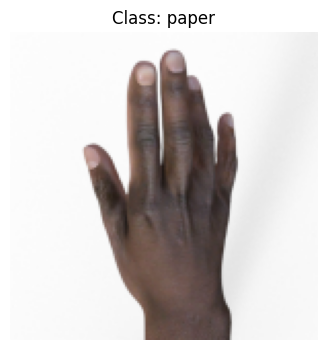

Image Shape: (150, 150, 3)
Label: 0
Class Name: paper


In [66]:
class_names = train_dataset.class_names

for images, labels in train_dataset.take(1):
    plt.figure(figsize=(4, 4))
    plt.imshow(images[0].numpy().astype("uint8"))
    plt.title(f"Class: {class_names[labels[0]]}")
    plt.axis("off")
    plt.show()

    print("Image Shape:", images[0].shape)
    print("Label:", labels[0].numpy())
    print("Class Name:", class_names[labels[0]])

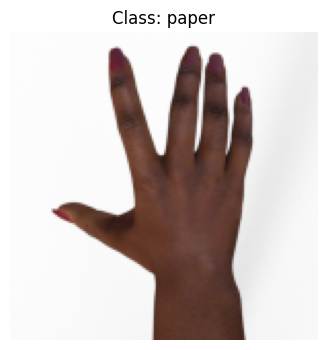

Image Shape: (150, 150, 3)
Label: 0
Class Name: paper


In [65]:
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(4, 4))
    plt.imshow(images[0].numpy().astype("uint8"))
    plt.title(f"Class: {class_names[labels[0]]}")
    plt.axis("off")
    plt.show()

    print("Image Shape:", images[0].shape)
    print("Label:", labels[0].numpy())
    print("Class Name:", class_names[labels[0]])

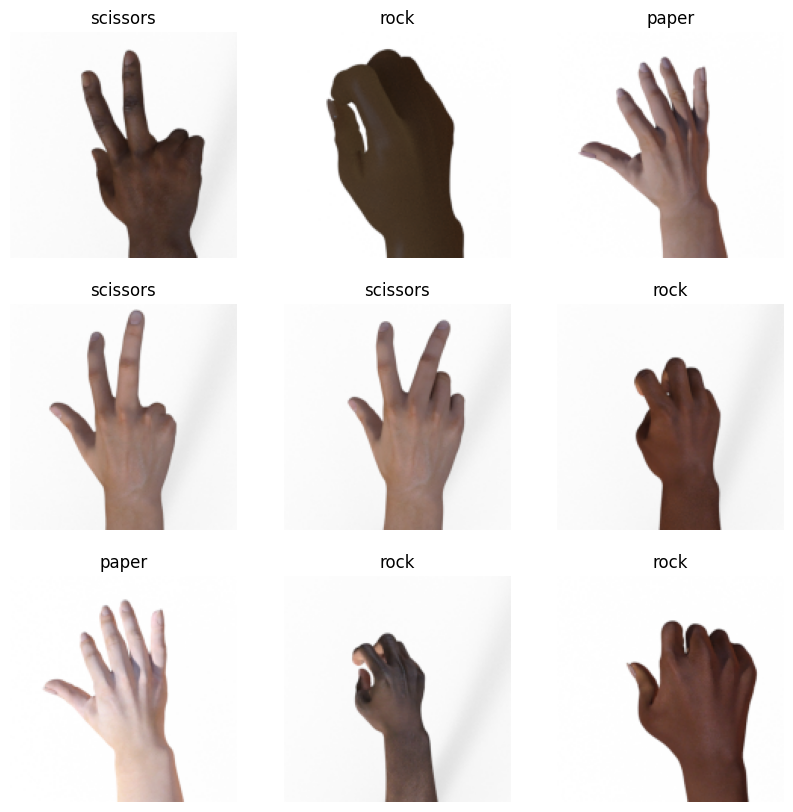

In [27]:
plt.figure(figsize=(10, 10))
for images,labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_name[labels[i]])
        plt.axis("off")
plt.show()

In [29]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))

In [31]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

## Build CNN

In [34]:
model=tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(3,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,183,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,222,115 (4.66 MB)

 Trainable params: 1,222,115 (4.66 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [44]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.7569 - loss: 0.5536 - val_accuracy: 0.9762 - val_loss: 0.1014
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9936 - loss: 0.0312 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.9990 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 1.0000 - loss: 6.8702e-04 - val_accuracy: 1.0000 - val_loss: 5.1211e-04
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 1.0000 - loss: 3.6083e-04 - val_accuracy: 1.0000 - val_loss: 3.2534e-04
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 1.0000 - loss: 2.4275e-04 - val_accuracy: 1.0000 - val_loss: 2.3880e-04
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 1.0000 - loss: 1.7596e-04 - val_accuracy: 1.0000 - val_loss: 1.7511e-04
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 1.0000 - loss: 1.3302

In [45]:
loss, accuracy = model.evaluate(validation_dataset)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 411ms/step - accuracy: 1.0000 - loss: 6.4241e-05
Validation Loss: 6.424122693715617e-05
Validation Accuracy: 1.0


Plot Accuracy

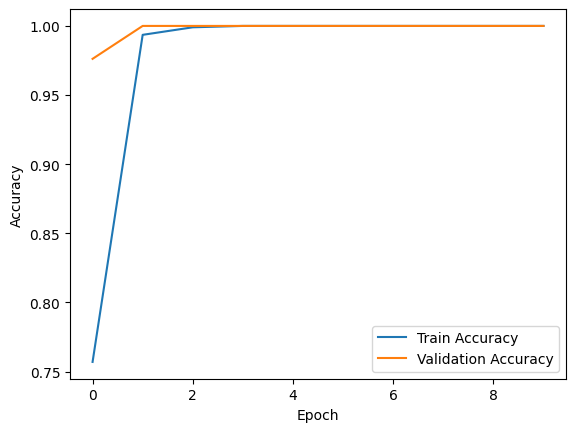

In [46]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Plot Loss

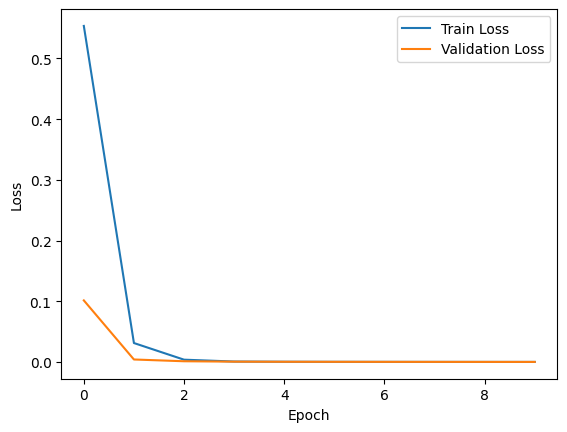

In [47]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()